In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import gc
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback)
from transformers import logging
logging.set_verbosity_error()

In [ ]:
df = pd.read_csv("FINAL_cleaned_annotations_RESOLVED1.csv")

In [ ]:
texts = df["cleaned_text"].astype(str)
labels = df["final_sentiment"]

In [ ]:
le = LabelEncoder()
y = le.fit_transform(labels)
num_labels = len(le.classes_)

In [ ]:
train_texts_full, test_texts, train_labels_full, test_labels = train_test_split(
    df["cleaned_text"].astype(str), y, test_size=0.2, random_state=42, stratify=y
)

# Inner split: 80% train, 20% validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts_full, train_labels_full, test_size=0.2, random_state=42, stratify=train_labels_full
)

print(f"Training size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")

Training size: 5150
Validation size: 1288
Test size: 1610


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("dost-asti/RoBERTa-tl-sentiment-analysis")

def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score

model = AutoModelForSequenceClassification.from_pretrained(
    "dost-asti/RoBERTa-tl-sentiment-analysis",
    num_labels=num_labels
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    labels = pred.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
def run_experiment(batch_size, lr, epochs=10):
    print(f"\nRunning: batch={batch_size} | lr={lr}")

    model = AutoModelForSequenceClassification.from_pretrained(
        "dost-asti/RoBERTa-tl-sentiment-analysis",
        num_labels=num_labels
    )

    training_args = TrainingArguments(
        output_dir=f"./grid_bs{batch_size}_lr{lr}",
        eval_strategy="epoch",
        save_strategy="epoch",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=lr,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_steps=50,
        fp16=True,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    trainer.train()

    metrics = trainer.evaluate()
    f1 = metrics["eval_f1"]
    loss = metrics["eval_loss"]

    print(f"Validation F1 = {f1:.4f}")

    del trainer
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return f1, loss

In [ ]:
batch_sizes = [16, 32]
learning_rates = [2e-5, 3e-5, 5e-5]

results = []
best_f1 = 0
best_params = None

for bs in batch_sizes:
    for lr in learning_rates:
        f1, loss = run_experiment(bs, lr, epochs=10)

        results.append({
            "batch_size": bs,
            "learning_rate": lr,
            "loss": loss,
            "f1": f1
        })

        if f1 > best_f1:
            best_f1 = f1
            best_params = (bs, lr)

print("\nBEST CONFIG: ")
print(best_params, "F1:", round(best_f1, 4))


Running: batch=16 | lr=2e-05


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'loss': '0.8234', 'grad_norm': '31.92', 'learning_rate': '1.97e-05', 'epoch': '0.1553'}
{'loss': '0.6671', 'grad_norm': '9.501', 'learning_rate': '1.939e-05', 'epoch': '0.3106'}
{'loss': '0.6101', 'grad_norm': '16.55', 'learning_rate': '1.907e-05', 'epoch': '0.4658'}
{'loss': '0.5337', 'grad_norm': '14.4', 'learning_rate': '1.876e-05', 'epoch': '0.6211'}
{'loss': '0.5383', 'grad_norm': '10.33', 'learning_rate': '1.845e-05', 'epoch': '0.7764'}
{'loss': '0.4907', 'grad_norm': '32.07', 'learning_rate': '1.814e-05', 'epoch': '0.9317'}
{'eval_loss': '0.4227', 'eval_accuracy': '0.8323', 'eval_f1': '0.8318', 'eval_runtime': '9.734', 'eval_samples_per_second': '132.3', 'eval_steps_per_second': '8.321', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4278', 'grad_norm': '19.14', 'learning_rate': '1.783e-05', 'epoch': '1.087'}
{'loss': '0.34', 'grad_norm': '22.99', 'learning_rate': '1.752e-05', 'epoch': '1.242'}
{'loss': '0.3613', 'grad_norm': '7.036', 'learning_rate': '1.721e-05', 'epoch': '1.398'}
{'loss': '0.2849', 'grad_norm': '9.475', 'learning_rate': '1.69e-05', 'epoch': '1.553'}
{'loss': '0.3719', 'grad_norm': '19.15', 'learning_rate': '1.659e-05', 'epoch': '1.708'}
{'loss': '0.2998', 'grad_norm': '10.43', 'learning_rate': '1.628e-05', 'epoch': '1.863'}
{'eval_loss': '0.3847', 'eval_accuracy': '0.8564', 'eval_f1': '0.8566', 'eval_runtime': '9.412', 'eval_samples_per_second': '136.8', 'eval_steps_per_second': '8.606', 'epoch': '2'}


...

{'loss': '0.1195', 'grad_norm': '2.725', 'learning_rate': '3.45e-05', 'epoch': '3.106'}
{'loss': '0.1056', 'grad_norm': '6.237', 'learning_rate': '3.295e-05', 'epoch': '3.416'}
{'loss': '0.1269', 'grad_norm': '24.71', 'learning_rate': '3.14e-05', 'epoch': '3.727'}
{'eval_loss': '0.4444', 'eval_accuracy': '0.8866', 'eval_f1': '0.8874', 'eval_runtime': '9.197', 'eval_samples_per_second': '140.1', 'eval_steps_per_second': '4.458', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1095', 'grad_norm': '9.314', 'learning_rate': '2.984e-05', 'epoch': '4.037'}
{'loss': '0.06228', 'grad_norm': '10.58', 'learning_rate': '2.829e-05', 'epoch': '4.348'}
{'loss': '0.0702', 'grad_norm': '0.247', 'learning_rate': '2.674e-05', 'epoch': '4.658'}
{'loss': '0.05758', 'grad_norm': '5.252', 'learning_rate': '2.519e-05', 'epoch': '4.969'}
{'eval_loss': '0.6255', 'eval_accuracy': '0.8812', 'eval_f1': '0.8817', 'eval_runtime': '9.153', 'eval_samples_per_second': '140.7', 'eval_steps_per_second': '4.479', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '802', 'train_samples_per_second': '64.21', 'train_steps_per_second': '2.007', 'train_loss': '0.2514', 'epoch': '5'}
{'eval_loss': '0.3604', 'eval_accuracy': '0.8602', 'eval_f1': '0.8603', 'eval_runtime': '8.895', 'eval_samples_per_second': '144.8', 'eval_steps_per_second': '4.609', 'epoch': '5'}
Validation F1 = 0.8603

BEST CONFIG: 
(16, 3e-05) F1: 0.8637


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("f1", ascending=False)

print(results_df)

   batch_size  learning_rate      loss        f1
1          16        0.00003  0.394462  0.863708
5          32        0.00005  0.360368  0.860252
0          16        0.00002  0.383914  0.857366
2          16        0.00005  0.395675  0.850408
3          32        0.00002  0.403468  0.844263
4          32        0.00003  0.384990  0.842750


In [ ]:
best_bs, best_lr = best_params

print("\nTraining FINAL model with best hyperparameters:")

model = AutoModelForSequenceClassification.from_pretrained(
    "dost-asti/RoBERTa-tl-sentiment-analysis",
    num_labels=num_labels
)

training_args = TrainingArguments(
    output_dir="./best_roberta_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=45,
    per_device_train_batch_size=best_bs,
    per_device_eval_batch_size=best_bs,
    learning_rate=best_lr,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=50,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

trainer.train()


Training FINAL model with best hyperparameters:


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'loss': '0.8242', 'grad_norm': '33.28', 'learning_rate': '2.99e-05', 'epoch': '0.1553'}
{'loss': '0.6358', 'grad_norm': '8.433', 'learning_rate': '2.98e-05', 'epoch': '0.3106'}
{'loss': '0.5902', 'grad_norm': '13.66', 'learning_rate': '2.969e-05', 'epoch': '0.4658'}
{'loss': '0.5055', 'grad_norm': '12.03', 'learning_rate': '2.959e-05', 'epoch': '0.6211'}
{'loss': '0.5377', 'grad_norm': '8.407', 'learning_rate': '2.948e-05', 'epoch': '0.7764'}
{'loss': '0.49', 'grad_norm': '16.86', 'learning_rate': '2.938e-05', 'epoch': '0.9317'}
{'eval_loss': '0.4492', 'eval_accuracy': '0.8416', 'eval_f1': '0.8421', 'eval_runtime': '9.401', 'eval_samples_per_second': '137', 'eval_steps_per_second': '8.616', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.4132', 'grad_norm': '49.72', 'learning_rate': '2.928e-05', 'epoch': '1.087'}
{'loss': '0.338', 'grad_norm': '39.16', 'learning_rate': '2.917e-05', 'epoch': '1.242'}
{'loss': '0.3563', 'grad_norm': '11.26', 'learning_rate': '2.907e-05', 'epoch': '1.398'}
{'loss': '0.2926', 'grad_norm': '12.34', 'learning_rate': '2.897e-05', 'epoch': '1.553'}
{'loss': '0.3435', 'grad_norm': '18.31', 'learning_rate': '2.886e-05', 'epoch': '1.708'}
{'loss': '0.2851', 'grad_norm': '8.564', 'learning_rate': '2.876e-05', 'epoch': '1.863'}
{'eval_loss': '0.3821', 'eval_accuracy': '0.8626', 'eval_f1': '0.8636', 'eval_runtime': '9.603', 'eval_samples_per_second': '134.1', 'eval_steps_per_second': '8.435', 'epoch': '2'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.03492', 'grad_norm': '27.05', 'learning_rate': '2.596e-05', 'epoch': '6.056'}
{'loss': '0.03075', 'grad_norm': '0.00267', 'learning_rate': '2.586e-05', 'epoch': '6.211'}
{'loss': '0.03158', 'grad_norm': '0.002322', 'learning_rate': '2.576e-05', 'epoch': '6.366'}
{'loss': '0.05986', 'grad_norm': '0.005195', 'learning_rate': '2.565e-05', 'epoch': '6.522'}
{'loss': '0.07078', 'grad_norm': '0.05337', 'learning_rate': '2.555e-05', 'epoch': '6.677'}
{'loss': '0.05587', 'grad_norm': '0.5324', 'learning_rate': '2.545e-05', 'epoch': '6.832'}
{'loss': '0.05192', 'grad_norm': '3.372', 'learning_rate': '2.534e-05', 'epoch': '6.988'}
{'eval_loss': '0.8417', 'eval_accuracy': '0.8657', 'eval_f1': '0.8654', 'eval_runtime': '9.578', 'eval_samples_per_second': '134.5', 'eval_steps_per_second': '8.457', 'epoch': '7'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1230', 'train_samples_per_second': '188.4', 'train_steps_per_second': '11.78', 'train_loss': '0.2149', 'epoch': '7'}


TrainOutput(global_step=2254, training_loss=0.21485827267752544, metrics={'train_runtime': 1230.0967, 'train_samples_per_second': 188.4, 'train_steps_per_second': 11.78, 'train_loss': 0.21485827267752544, 'epoch': 7.0})

In [ ]:
pred_test = trainer.predict(test_dataset)
preds_test = np.argmax(pred_test.predictions, axis=1)

print(classification_report(test_labels, preds_test, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.84      0.84      0.84       489
     neutral       0.79      0.85      0.82       564
    positive       0.96      0.89      0.92       557

    accuracy                           0.86      1610
   macro avg       0.86      0.86      0.86      1610
weighted avg       0.86      0.86      0.86      1610



In [ ]:
test_df = df.iloc[test_texts.index].copy()
test_df["predicted_sentiment"] = le.inverse_transform(preds_test)

counts = (
    test_df
    .groupby(["duo", "predicted_sentiment"])
    .size()
    .unstack(fill_value=0)
)

# Compute score
counts["score"] = (counts["positive"] - counts["negative"]) / \
                  (counts["positive"] + counts["negative"])

exp_scores = np.exp(counts["score"])
counts["percentage"] = exp_scores / exp_scores.sum() * 100

result = counts.sort_values("percentage", ascending=False)
print(result)

predicted_sentiment  negative  neutral  positive     score  percentage
duo                                                                   
RaWi                       62      189       168  0.460870   35.809053
BreKa                      90      147       161  0.282869   29.970085
CharEs                    146      129       143 -0.010381   22.352777
AzVer                     189      145        41 -0.643478   11.868086


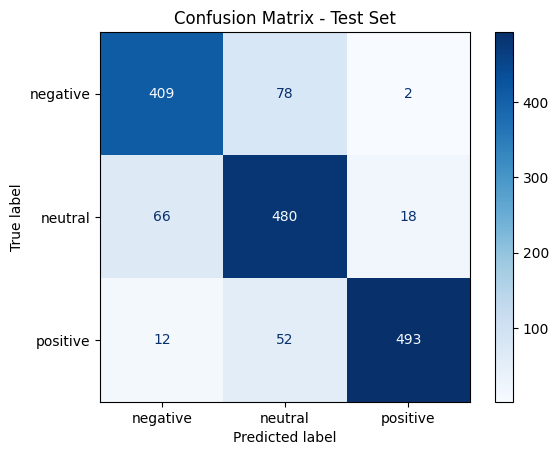

In [ ]:
cm = confusion_matrix(test_labels, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

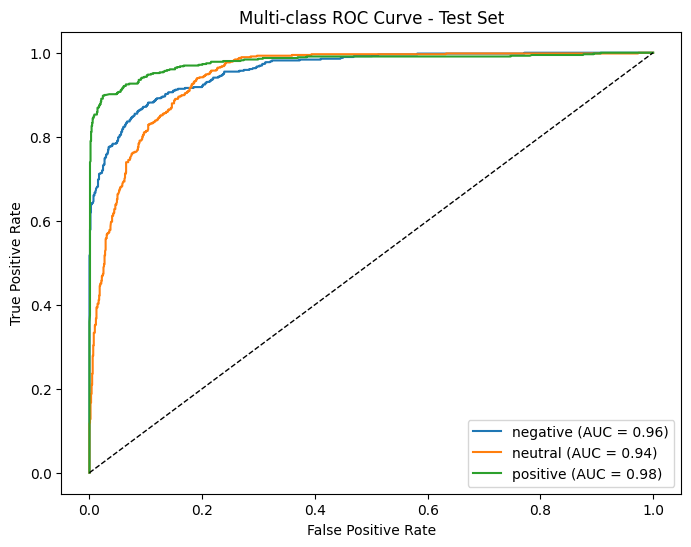

In [ ]:
y_test_bin = label_binarize(test_labels, classes=range(num_labels))
y_score = pred_test.predictions

plt.figure(figsize=(8,6))
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve - Test Set")
plt.legend(loc="lower right")
plt.show()